In [1]:
import requests
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from io import StringIO
from pathlib import Path
from tqdm.notebook import tqdm

print("All imports successful")
print(f"Pandas version: {pd.__version__}")
print(f"GeoPandas version: {gpd.__version__}")

All imports successful
Pandas version: 2.3.3
GeoPandas version: 1.1.3


In [2]:
# ── IEM API endpoint ──────────────────────────────────────────────────────────
IEM_URL = "https://mesonet.agron.iastate.edu/cgi-bin/request/gis/lsr.py"

# ── Study period: full warm season 2024 ──────────────────────────────────────
MONTHS = [
    ("2024-04-01T00:00Z", "2024-04-30T23:59Z", "April"),
    ("2024-05-01T00:00Z", "2024-05-31T23:59Z", "May"),
    ("2024-06-01T00:00Z", "2024-06-30T23:59Z", "June"),
    ("2024-07-01T00:00Z", "2024-07-31T23:59Z", "July"),
    ("2024-08-01T00:00Z", "2024-08-31T23:59Z", "August"),
    ("2024-09-01T00:00Z", "2024-09-30T23:59Z", "September"),
]

# ── CONUS bounding box for QC filtering ───────────────────────────────────────
CONUS_LON_MIN, CONUS_LON_MAX = -125.0, -66.0
CONUS_LAT_MIN, CONUS_LAT_MAX =   24.0,  50.0

print("Constants defined")
print(f"Study period: {MONTHS[0][0]} to {MONTHS[-1][1]}")
print(f"CONUS bounds: lon [{CONUS_LON_MIN}, {CONUS_LON_MAX}], lat [{CONUS_LAT_MIN}, {CONUS_LAT_MAX}]")

Constants defined
Study period: 2024-04-01T00:00Z to 2024-09-30T23:59Z
CONUS bounds: lon [-125.0, -66.0], lat [24.0, 50.0]


In [3]:
def fetch_lsrs_for_month(start, end, label):
    """
    Fetch ALL LSR types from IEM for a single month, then filter
    to Flash Flood (TYPECODE == 'F') in Python.
    
    The IEM type filter parameter is unreliable so we fetch everything
    and filter ourselves — more robust and reproducible.
    
    on_bad_lines='skip' handles remarks with commas in them which
    break the CSV parser.
    """
    params = {
        "sts":  start,
        "ets":  end,
        "wfo":  "ALL",
        "fmt":  "csv",
    }

    print(f"  Fetching {label} ({start[:10]} to {end[:10]})...")

    r = requests.get(IEM_URL, params=params, timeout=120)
    r.raise_for_status()

    lines = [l for l in r.text.splitlines() if not l.startswith("#")]

    if len(lines) <= 1:
        print(f"    WARNING: No data returned for {label}")
        return pd.DataFrame()

    df = pd.read_csv(
        StringIO("\n".join(lines)),
        on_bad_lines="skip"   # skip rows where commas in REMARK break parsing
    )

    total = len(df)
    df = df[df["TYPECODE"] == "F"].reset_index(drop=True)
    print(f"    {total:,} total LSRs → {len(df):,} Flash Flood only")
    return df

print("Fetch function redefined")

Fetch function redefined


In [13]:
print("=" * 55)
print("Fetching Flash Flood LSRs — April through September 2024")
print("=" * 55)

monthly_frames = []

for start, end, label in MONTHS:
    df = fetch_lsrs_for_month(start, end, label)
    if not df.empty:
        monthly_frames.append(df)

# Combine all months into one DataFrame
lsr_raw = pd.concat(monthly_frames, ignore_index=True)

print()
print(f"Total raw LSRs across all months: {len(lsr_raw):,}")

# Save raw immediately — this file is never modified
lsr_raw.to_parquet("../data/lsr_raw_ws2024.parquet", index=False)
print("Raw data saved to data/lsr_raw_ws2024.parquet")

Fetching Flash Flood LSRs — April through September 2024
  Fetching April (2024-04-01 to 2024-04-30)...
    17,947 total LSRs → 699 Flash Flood only
  Fetching May (2024-05-01 to 2024-05-31)...
    20,528 total LSRs → 863 Flash Flood only
  Fetching June (2024-06-01 to 2024-06-30)...
    14,869 total LSRs → 721 Flash Flood only
  Fetching July (2024-07-01 to 2024-07-31)...
    13,267 total LSRs → 1,051 Flash Flood only
  Fetching August (2024-08-01 to 2024-08-31)...
    12,859 total LSRs → 1,154 Flash Flood only
  Fetching September (2024-09-01 to 2024-09-30)...
    6,400 total LSRs → 635 Flash Flood only

Total raw LSRs across all months: 5,123
Raw data saved to data/lsr_raw_ws2024.parquet


In [14]:
# ── Basic shape and structure ─────────────────────────────────────────────────
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Total Flash Flood LSRs: {len(lsr_raw):,}")
print(f"Columns: {lsr_raw.columns.tolist()}")
print(f"Date range: {lsr_raw['VALID'].min()} → {lsr_raw['VALID'].max()}")
print(f"Unique WFOs: {lsr_raw['WFO'].nunique()}")

# ── Monthly counts ────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("LSRs PER MONTH")
print("=" * 55)
lsr_raw["VALID"] = lsr_raw["VALID"].astype(str)
lsr_raw["month"] = lsr_raw["VALID"].str[:6]  # YYYYMM
print(lsr_raw.groupby("month").size().rename("count").to_string())

# ── Top 10 most active WFOs ───────────────────────────────────────────────────
print("\n" + "=" * 55)
print("TOP 10 MOST ACTIVE WFOs")
print("=" * 55)
print(lsr_raw["WFO"].value_counts().head(10).to_string())

# ── Look at actual remarks — this is the ground truth ─────────────────────────
print("\n" + "=" * 55)
print("10 RANDOM REMARKS — read these, this is real ground truth")
print("=" * 55)
for i, row in lsr_raw.sample(10, random_state=42).iterrows():
    print(f"\n[{row['WFO']}] {row['VALID']} — {row['CITY']}, {row['STATE']}")
    print(f"  {row['REMARK']}")

# ── Check for obvious data problems ──────────────────────────────────────────
print("\n" + "=" * 55)
print("DATA QUALITY CHECK")
print("=" * 55)
print(f"Rows with missing LAT:  {lsr_raw['LAT'].isna().sum()}")
print(f"Rows with missing LON:  {lsr_raw['LON'].isna().sum()}")
print(f"Rows with missing WFO:  {lsr_raw['WFO'].isna().sum()}")
print(f"LAT range: {lsr_raw['LAT'].min():.2f} → {lsr_raw['LAT'].max():.2f}")
print(f"LON range: {lsr_raw['LON'].min():.2f} → {lsr_raw['LON'].max():.2f}")

DATASET OVERVIEW
Total Flash Flood LSRs: 5,123
Columns: ['VALID', 'VALID2', 'LAT', 'LON', 'MAG', 'WFO', 'TYPECODE', 'TYPETEXT', 'CITY', 'COUNTY', 'STATE', 'SOURCE', 'REMARK', 'UGC', 'UGCNAME', 'QUALIFIER']
Date range: 202404011250 → 202409302333
Unique WFOs: 104

LSRs PER MONTH
month
202404     699
202405     863
202406     721
202407    1051
202408    1154
202409     635

TOP 10 MOST ACTIVE WFOs
WFO
TAE    307
PBZ    230
LCH    184
ABQ    181
AKQ    177
JSJ    177
FWD    171
RNK    143
OKX    140
SGF    131

10 RANDOM REMARKS — read these, this is real ground truth

[GYX] 202404121810 — 4 ESE Stratton, ME
  Corrects previous flood report from 4 ESE Stratton. Delayed report. Stratton Brook Pond Rd closed due to flooding.

[FWD] 202406051300 — 2 N Sherman, TX
  Flooding reported at HWY 75 and Travis Blvd.

[PAH] 202405082218 — Simpson, IL
  nan

[OUN] 202405160101 — 2 W Kildare, OK
  Report from mPING: Street/road flooding;.

[FWD] 202405240440 — 3 N Whitesboro, TX
  Emergency managemen

In [ ]:
import numpy as np

# ── Build 0.5-degree grid ─────────────────────────────────────────────────────
lon_bins = np.arange(-125, -66, 0.5)
lat_bins = np.arange(24, 50, 0.5)

density, _, _ = np.histogram2d(
    lsr_qc["LON"],
    lsr_qc["LAT"],
    bins=[lon_bins, lat_bins]
)
density = density.T
lon_centers = lon_bins[:-1] + 0.25
lat_centers = lat_bins[:-1] + 0.25
lon_grid, lat_grid = np.meshgrid(lon_centers, lat_centers)

# ── Compute meaningful spotter density threshold ──────────────────────────────
nonzero = density[density > 0]
p25  = np.percentile(nonzero, 25)
p50  = np.percentile(nonzero, 50)
p75  = np.percentile(nonzero, 75)

print("Spotter density distribution (nonzero cells only):")
print(f"  25th percentile: {p25:.1f} LSRs per 0.5° cell  ← too low, not useful")
print(f"  50th percentile: {p50:.1f} LSRs per 0.5° cell  ← median coverage")
print(f"  75th percentile: {p75:.1f} LSRs per 0.5° cell  ← well covered threshold")
print(f"\nWe use {p75:.1f} as the spotter density threshold.")
print(f"Cells above threshold: {(density >= p75).sum():,}")
print(f"Cells below threshold (spotter-sparse): {(density < p75).sum():,}")

SPOTTER_DENSITY_THRESHOLD = p75

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(
    figsize=(14, 8),
    subplot_kw={"projection": ccrs.LambertConformal()}
)

ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor="gray")   # state borders
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor="black")
ax.add_feature(cfeature.OCEAN, facecolor="lightcyan")
ax.add_feature(cfeature.LAND, facecolor="whitesmoke", zorder=0)

density_masked = np.ma.masked_where(density == 0, density)

mesh = ax.pcolormesh(
    lon_grid, lat_grid, density_masked,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    vmin=1, vmax=30,
    zorder=4
)

cbar = plt.colorbar(mesh, ax=ax, orientation="vertical", pad=0.02, shrink=0.7)
cbar.set_label("LSR count per 0.5° grid cell", fontsize=11)
cbar.ax.axhline(y=SPOTTER_DENSITY_THRESHOLD, color="blue", linewidth=2, 
                label=f"75th pct threshold ({SPOTTER_DENSITY_THRESHOLD:.1f})")

ax.set_title(
    "Flash Flood LSR Density — CONUS Warm Season 2024\n"
    "(0.5° grid cells — used for spotter density bias analysis)",
    fontsize=12, fontweight="bold"
)

plt.tight_layout()
plt.savefig("../figures/lsr_density.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → figures/lsr_density.png")
print(f"Spotter density threshold locked at: {SPOTTER_DENSITY_THRESHOLD:.1f}")

QUALITY CONTROL
Starting rows: 5,123

Step 1 — CONUS bounding box filter:
  Removed 209 rows outside CONUS
  Remaining: 4,914

Step 2 — Duplicate report removal:
  Removed 184 duplicate reports
  Remaining: 4,730

Final clean dataset: 4,730 LSRs
Removed total: 393 rows (7.7%)
LAT range after QC: 25.60 → 48.76
LON range after QC: -120.35 → -68.45


In [15]:
lsr_qc.to_parquet("../data/lsr_clean_ws2024.parquet", engine="fastparquet", index=False)
print(f"Clean data saved → data/lsr_clean_ws2024.parquet")
print(f"Shape: {lsr_qc.shape}")

Clean data saved → data/lsr_clean_ws2024.parquet
Shape: (4730, 17)


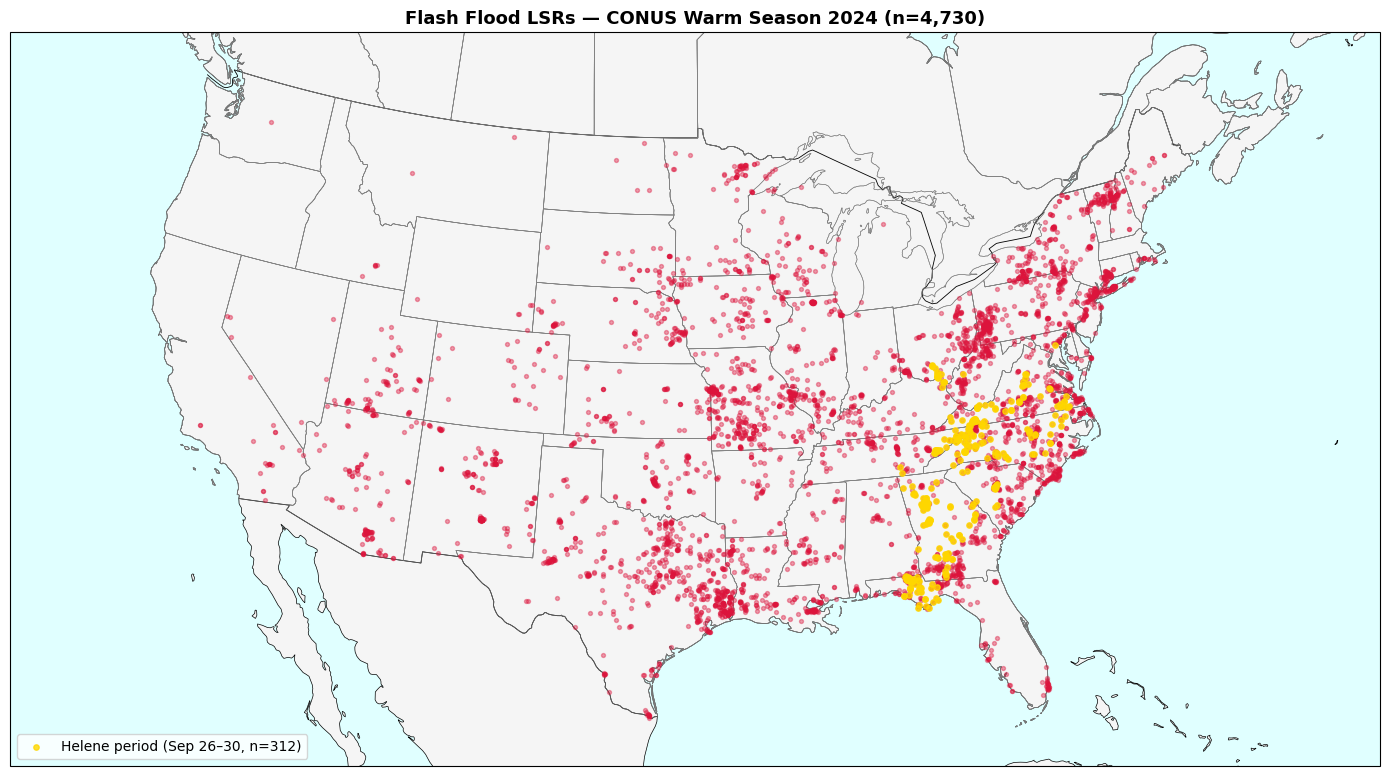

Saved → figures/lsr_locations.png


In [16]:
fig, ax = plt.subplots(
    figsize=(14, 8),
    subplot_kw={"projection": ccrs.LambertConformal()}
)

# ── Map extent and features ───────────────────────────────────────────────────
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor="gray")
ax.add_feature(cfeature.BORDERS, linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="whitesmoke")
ax.add_feature(cfeature.OCEAN, facecolor="lightcyan")
ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor="gray")

# ── Plot LSR points ───────────────────────────────────────────────────────────
ax.scatter(
    lsr_qc["LON"],
    lsr_qc["LAT"],
    transform=ccrs.PlateCarree(),
    s=8,
    alpha=0.4,
    color="crimson",
    zorder=5
)

# ── Highlight Helene cluster ──────────────────────────────────────────────────
helene = lsr_qc[lsr_qc["valid_str"] if "valid_str" in lsr_qc.columns 
                else lsr_qc["VALID"].astype(str).str[:8] >= "20240926"]
helene = lsr_qc[lsr_qc["VALID"].astype(str).str[:8] >= "20240926"]
ax.scatter(
    helene["LON"],
    helene["LAT"],
    transform=ccrs.PlateCarree(),
    s=15,
    alpha=0.8,
    color="gold",
    zorder=6,
    label=f"Helene period (Sep 26–30, n={len(helene):,})"
)

ax.legend(loc="lower left", fontsize=10)
ax.set_title(
    f"Flash Flood LSRs — CONUS Warm Season 2024 (n={len(lsr_qc):,})",
    fontsize=13, fontweight="bold"
)

plt.tight_layout()
plt.savefig("../figures/lsr_locations.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/lsr_locations.png")

Spotter density distribution (nonzero cells only):
  25th percentile: 1.0 LSRs per 0.5° cell  ← too low, not useful
  50th percentile: 2.0 LSRs per 0.5° cell  ← median coverage
  75th percentile: 5.0 LSRs per 0.5° cell  ← well covered threshold

We use 5.0 as the spotter density threshold.
Cells above threshold: 303
Cells below threshold (spotter-sparse): 5,664


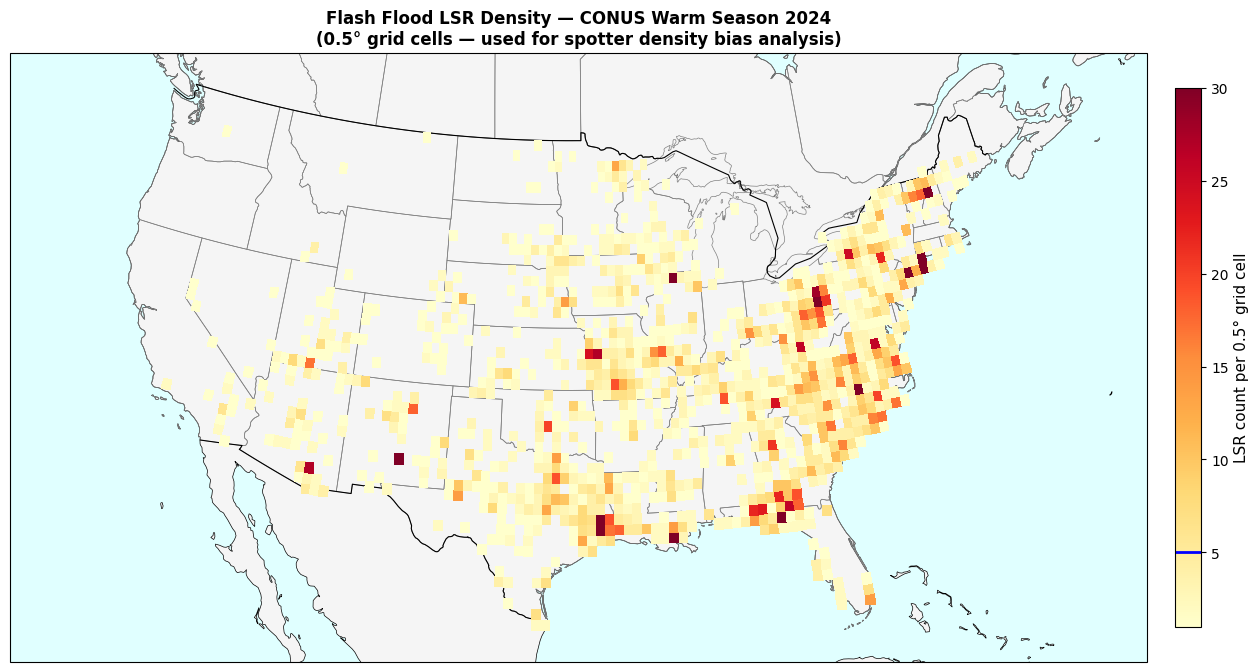

Saved → figures/lsr_density.png
Spotter density threshold locked at: 5.0


In [17]:
import numpy as np

# ── Build 0.5-degree grid ─────────────────────────────────────────────────────
lon_bins = np.arange(-125, -66, 0.5)
lat_bins = np.arange(24, 50, 0.5)

density, _, _ = np.histogram2d(
    lsr_qc["LON"],
    lsr_qc["LAT"],
    bins=[lon_bins, lat_bins]
)
density = density.T
lon_centers = lon_bins[:-1] + 0.25
lat_centers = lat_bins[:-1] + 0.25
lon_grid, lat_grid = np.meshgrid(lon_centers, lat_centers)

# ── Compute meaningful spotter density threshold ──────────────────────────────
nonzero = density[density > 0]
p25  = np.percentile(nonzero, 25)
p50  = np.percentile(nonzero, 50)
p75  = np.percentile(nonzero, 75)

print("Spotter density distribution (nonzero cells only):")
print(f"  25th percentile: {p25:.1f} LSRs per 0.5° cell  ← too low, not useful")
print(f"  50th percentile: {p50:.1f} LSRs per 0.5° cell  ← median coverage")
print(f"  75th percentile: {p75:.1f} LSRs per 0.5° cell  ← well covered threshold")
print(f"\nWe use {p75:.1f} as the spotter density threshold.")
print(f"Cells above threshold: {(density >= p75).sum():,}")
print(f"Cells below threshold (spotter-sparse): {(density < p75).sum():,}")

SPOTTER_DENSITY_THRESHOLD = p75

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(
    figsize=(14, 8),
    subplot_kw={"projection": ccrs.LambertConformal()}
)

ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor="gray")   # state borders
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor="black")
ax.add_feature(cfeature.OCEAN, facecolor="lightcyan")
ax.add_feature(cfeature.LAND, facecolor="whitesmoke", zorder=0)

density_masked = np.ma.masked_where(density == 0, density)

mesh = ax.pcolormesh(
    lon_grid, lat_grid, density_masked,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    vmin=1, vmax=30,
    zorder=4
)

cbar = plt.colorbar(mesh, ax=ax, orientation="vertical", pad=0.02, shrink=0.7)
cbar.set_label("LSR count per 0.5° grid cell", fontsize=11)
cbar.ax.axhline(y=SPOTTER_DENSITY_THRESHOLD, color="blue", linewidth=2, 
                label=f"75th pct threshold ({SPOTTER_DENSITY_THRESHOLD:.1f})")

ax.set_title(
    "Flash Flood LSR Density — CONUS Warm Season 2024\n"
    "(0.5° grid cells — used for spotter density bias analysis)",
    fontsize=12, fontweight="bold"
)

plt.tight_layout()
plt.savefig("../figures/lsr_density.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → figures/lsr_density.png")
print(f"Spotter density threshold locked at: {SPOTTER_DENSITY_THRESHOLD:.1f}")